<a href="https://colab.research.google.com/github/MinsooKwak/RAG/blob/main/test/preprocessing/arvix_cat_extract_test_v0_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Library**

In [ ]:
!pip install -qU langchain-community arxiv pymupdf pdf2image pypdf PyPDF2
!pip install tiktoken
!pip install --upgrade pymupdf

In [2]:
import config
import os
os.environ["OPENAI_API_KEY"] = config.OPEN_AI_API_KEY
os.environ["HUGGINGFACE_API_KEY"] = config.HUGGINGFACE_API_KEY
os.environ["LANGCHAIN_TRACING_V2"] = config.LANGCHAIN_TRACING_V2
os.environ["LANGCHAIN_ENDPOINT"] = config.LANGCHAIN_ENDPOINT
os.environ["LANGCHAIN_API_KEY"] = config.LANGCHAIN_API_KEY

**카테고리별로 가져올 수 있는지 확인 (가능)**

- 카테고리 정보 : https://arxiv.org/category_taxonomy
- 검색어 search (web) : https://arxiv.org/search/

- 대분류 / 소분류별 가져오기 (따로 구성)
  - 우선 대분류 진행
  - 추후 고도화시 소분류 반영 (이는 어떤 카테고리에서 분석이 부족한지 반영할 수 있음)

In [ ]:
#major_categories = ["cs", "math", "physics", "eess", "econ", "q-bio", "q-fin", "stat", "astro-ph"] # 아래 수정

In [ ]:
import os
import pandas as pd
from langchain.document_loaders import ArxivLoader
from langchain.document_loaders import PyPDFLoader
from pdf2image import convert_from_path
from huggingface_hub import hf_hub_download
#import cv2
#from doclayout_yolo import YOLOv10
from PIL import Image

# ArxivLoader를 활용해 논문을 가져옵니다
loader = ArxivLoader(
    query= "cat : q-bio.*",               # 카테고리별 추출 가능 여부 Test  #f"cat:{category}"
    load_max_docs=50,               # 최대 문서 수
    load_all_available_meta=True    # 메타데이터 전체 로드 여부
)
docs = loader.load()

print(f"Loaded documents: {len(docs)}")


# 메타데이터 정보를 데이터프레임으로 저장
metadata_list = []
for doc in docs:
    metadata = doc.metadata
    metadata_list.append({
        'Title': metadata.get('Title', ''),
        'Summary': metadata.get('Summary', ''),
        'PDF Link': metadata.get('links', [])[-1] if metadata.get('links') else ''
    })

dataframe = pd.DataFrame(metadata_list)

# 데이터프레임 확인
print(dataframe)

Loaded documents: 3
                                   Title  \
0      Semistability and CAT(0) Geometry   
1                  Quantum Mona Lisa Cat   
2  On the Topological Complexity of Maps   

                                             Summary  \
0  We explain why semistability of a one-ended pr...   
1  Schr\"{o}dinger's Cat was proposed by Erwin Sc...   
2  We define and develop a homotopy invariant not...   

                            PDF Link  
0  http://arxiv.org/pdf/1703.07003v1  
1  http://arxiv.org/pdf/2001.10184v2  
2  http://arxiv.org/pdf/2011.10646v1  


In [ ]:
dataframe.head()

,Title,Summary,PDF Link
0,Semistability and CAT(0) Geometry,We explain why semistability of a one-ended pr...,http://arxiv.org/pdf/1703.07003v1
1,Quantum Mona Lisa Cat,"Schr\""{o}dinger's Cat was proposed by Erwin Sc...",http://arxiv.org/pdf/2001.10184v2
2,On the Topological Complexity of Maps,We define and develop a homotopy invariant not...,http://arxiv.org/pdf/2011.10646v1


In [ ]:
test_queries_lst = ["cat : cs.*", "cat : math.*", "cat : physics.*", "cat : eess.*", "cat : econ.*", "cat : q-bio.*", "cat : q-fin*", "cat : stat*", "cat : astro-ph.*"]
len(test_queries_lst)

9

In [ ]:
# 전체 카테고리(대분류) 추출 코드 (arxivloader편) - 미사용
import os
import pandas as pd
from langchain.document_loaders import ArxivLoader

# 쿼리 리스트 및 각 쿼리에 따른 최대 문서 수 설정
queries = ["cat : cs.*", "cat : math.*", "cat : physics.*", "cat : eess.*", "cat : econ.*", "cat : q-bio.*", "cat : q-fin*", "cat : stat*", "cat : astro-ph.*"]
load_max_docs_list = [5, 5, 5, 5, 5, 5, 5, 5, 5]  # 9개의 category이므로 우선 5개씩 저장해서 활용

# 결과를 저장할 리스트 초기화
metadata_list = []

# 각 쿼리에 대해 문서 로드 및 처리
for query, max_docs in zip(queries, load_max_docs_list):
    # ArxivLoader를 통해 문서 로드
    loader = ArxivLoader(
        query=query,                  # 현재 쿼리
        load_max_docs=max_docs,       # 최대 문서 수
        load_all_available_meta=True  # 메타데이터 전체 로드
    )
    docs = loader.load()

    # 각 문서에 대해 메타데이터 추출 및 저장
    for doc in docs:
        metadata = doc.metadata
        metadata_list.append({
            'Query': query,  # 쿼리 정보 추가
            'Title': metadata.get('Title', ''),
            'Summary': metadata.get('Summary', ''),
            'PDF Link': metadata.get('links', [])[-1] if metadata.get('links') else ''
        })

# 메타데이터 정보를 데이터프레임으로 변환
dataframe = pd.DataFrame(metadata_list)

# 데이터프레임 확인
print(dataframe)

# 데이터프레임 저장 (선택 사항)
output_path = "arxiv_metadata.csv"
dataframe.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"Metadata saved to {output_path}")

               Query                                              Title  \
0         cat : cs.*  Barut-Girardello coherent states for sp(N,C) a...   
1         cat : cs.*  Demonstrating CAT: Synthesizing Data-Aware Con...   
2         cat : cs.*             Undirected Cat-and-Mouse is P-complete   
3       cat : math.*  Random groups have fixed points on CAT(0) cube...   
4       cat : math.*  Low-dimensional representations of matrix grou...   
5       cat : math.*                                       Hydra groups   
6    cat : physics.*  Is it possible to suspend the spread of an epi...   
7    cat : physics.*                         Free Will and Falling Cats   
8    cat : physics.*                    A Requiem For Schrödinger's Cat   
9       cat : eess.*  CAT: A CTC-CRF based ASR Toolkit Bridging the ...   
10      cat : eess.*                         CAT: CRF-based ASR Toolkit   
11      cat : eess.*  Assessing the Circadian Rhythm of Cats Living ...   
12      cat : econ.*  Seq

In [ ]:
# Langchain 기반 Loader 설정 확인
from langchain.document_loaders import ArxivLoader
#help(ArxivLoader)

#!pip show langchain

In [ ]:
# Test

import requests
import xml.etree.ElementTree as ET

# ArXiv API URL 구성
url = "http://export.arxiv.org/api/query"
params = {
    "search_query": "cat:q-bio.*",
    "start": 0,
    "max_results": 50
}
response = requests.get(url, params=params)

# API 응답 확인
print(response.status_code)  # 응답 코드 (200이어야 정상)
#print(response.text)         # 응답 내용 출력

# XML 응답 파싱
root = ET.fromstring(response.text)
entries = root.findall('{http://www.w3.org/2005/Atom}entry')

# 논문 메타데이터 추출
metadata_list = []
for entry in entries:
    title = entry.find('{http://www.w3.org/2005/Atom}title').text
    summary = entry.find('{http://www.w3.org/2005/Atom}summary').text
    pdf_link = None
    for link in entry.findall('{http://www.w3.org/2005/Atom}link'):
        if link.attrib.get('title') == 'pdf':
            pdf_link = link.attrib['href']
            break
    metadata_list.append({'Title': title, 'Summary': summary, 'PDF Link': pdf_link})

# 결과 출력
for meta in metadata_list:
    print(meta)

print(f'len : {len(metadata_list)}')

200
{'Title': 'Acto-myosin clusters as active units shaping living matter', 'Summary': '  Stress generation by the actin cytoskeleton shapes cells and tissues. Despite\nimpressive progress in live imaging and quantitative physical descriptions of\ncytoskeletal network dynamics, the connection between processes at molecular\nscales and cell-scale spatio-temporal patterns is still unclear. Here we review\nstudies reporting acto-myosin clusters of micrometer size and with lifetimes of\nseveral minutes in a large number of organisms ranging from fission yeast to\nhumans. Such structures have also been found in reconstituted systems in vitro\nand in theoretical analysis of cytoskeletal dynamics. We propose that tracking\nthese clusters can serve as a simple readout for characterising living matter.\nSpatio-temporal patterns of clusters could serve as determinants of\nmorphogenetic processes that play similar roles in diverse organisms.\n', 'PDF Link': 'http://arxiv.org/pdf/2408.05119v1'}
{'

In [ ]:
df_bio_metadata_list = pd.DataFrame(metadata_list)
print(len(df_bio_metadata_list))
df_bio_metadata_list.head()

50


,Title,Summary,PDF Link
0,Acto-myosin clusters as active units shaping l...,Stress generation by the actin cytoskeleton ...,http://arxiv.org/pdf/2408.05119v1
1,Genome-scale reconstruction of the metabolic n...,"The gram-negative bacterium Yersinia pestis,...",http://arxiv.org/pdf/0903.4219v1
2,Infer metabolic velocities from moment differe...,Metabolic pathways are fundamental maps in b...,http://arxiv.org/pdf/2402.14887v4
3,Spatial cancer systems biology resolves hetero...,Spatially annotated single-cell datasets pro...,http://arxiv.org/pdf/2303.00933v1
4,Prediction of cellular burden with host-circui...,Heterologous gene expression draws resources...,http://arxiv.org/pdf/2004.00995v2


In [ ]:
!pip install -qU langchain-community arxiv pymupdf pdf2image pypdf PyPDF2

In [ ]:
# 전체 카테고리 (API 활용 방식)
import os
import pandas as pd
from langchain.document_loaders import ArxivLoader
from langchain.document_loaders import PyPDFLoader
from pdf2image import convert_from_path
from huggingface_hub import hf_hub_download
#import cv2
#from doclayout_yolo import YOLOv10
from PIL import Image
import time
import requests
import xml.etree.ElementTree as ET
from PyPDF2 import PdfReader
import io

# ArXiv API URL 구성
url = "http://export.arxiv.org/api/query"

# Query 리스트와 최대 문서 수 정의
# 쿼리 리스트 및 각 쿼리에 따른 최대 문서 수 설정
queries = ["cat : cs.*", "cat : math.*", "cat : physics.*", "cat : eess.*", "cat : econ.*", "cat : q-bio.*", "cat : q-fin.*", "cat : stat.*", "cat : astro-ph.*"]
load_max_docs_list = [5, 5, 5, 5, 5, 5, 5, 5, 5]  # 9개의 category이므로 우선 5개씩 저장해서 활용

#### 본문 저장하기 위한 함수 (PdfReader)
"""
def extract_text_from_pdf(pdf_url):
    try:
        response = requests.get(pdf_url)
        response.raise_for_status()  # 요청 성공 여부 확인

        with io.BytesIO(response.content) as pdf_file:
            reader = PdfReader(pdf_file)
            text = ""
            for page in reader.pages:
                text += page.extract_text()
        return text
    except Exception as e:
        print(f"Error extracting text from {pdf_url}: {e}")
        return None
"""
#### 본문 반영
def extract_text_from_pdf(pdf_url):
    try:
      response = requests.get(pdf_url)
      if response.status_code == 200:
        pdf_file = io.BytesIO(response.content)
        reader = PdfReader(pdf_file)
        full_text = ""
        for page in reader.pages:
          full_text += page.extract_text()
        return full_text
      else:
        return f"Failed to download PDF (status code: {response.status_code})"
    except Exception as e:
      return f"Error: {str(e)}"

# 메타데이터 저장
metadata_list = []

for query, max_docs in zip(queries, load_max_docs_list):
    params = {
        "search_query": query,
        "start": 0,
        "max_results": max_docs
    }

    response = requests.get(url, params=params)

    # API 응답 확인
    if response.status_code != 200:
        print(f"Error: Failed to fetch data for query '{query}' with status code {response.status_code}")
        continue

    # XML 응답 파싱
    root = ET.fromstring(response.text)
    entries = root.findall('{http://www.w3.org/2005/Atom}entry')

    # 논문 메타데이터 추출
    category = query.split(':')[1].split('.')[0]  # 'cat:' 이후, '.' 이전 부분 추출

    # 논문 메타데이터 추출
    for entry in entries:
        title = entry.find('{http://www.w3.org/2005/Atom}title').text
        summary = entry.find('{http://www.w3.org/2005/Atom}summary').text
        pdf_link = None
        for link in entry.findall('{http://www.w3.org/2005/Atom}link'):
            if link.attrib.get('title') == 'pdf':
                pdf_link = link.attrib['href']
                break

        metadata_list.append({
            'Category': category,
            'Query': query,
            'Title': title,
            'Summary': summary,
            'PDF Link': pdf_link,
        })

        # PDF 본문 추출 (PdfReader 일 때)
        #pdf_text = extract_text_from_pdf(pdf_link) if pdf_link else None

# 결과 출력
for meta in metadata_list:
    print(meta)

print(f'Total number of papers fetched: {len(metadata_list)}')

{'Category': ' cs', 'Query': 'cat : cs.*', 'Title': 'Brittle System Analysis', 'Summary': '  The goal of this paper is to define and analyze systems which exhibit brittle\nbehavior. This behavior is characterized by a sudden and steep decline in\nperformance as the system approaches the limits of tolerance. This can be due\nto input parameters which exceed a specified input, or environmental conditions\nwhich exceed specified operating boundaries. An analogy is made between brittle\ncommmunication systems in particular and materials science.\n', 'PDF Link': 'http://arxiv.org/pdf/cs/9904016v1'}
{'Category': ' cs', 'Query': 'cat : cs.*', 'Title': 'The Unix KISS: A Case Study', 'Summary': '  In this paper we show that the initial philosophy used in designing and\ndeveloping UNIX in early times has been forgotten due to "fast practices". We\nquestion the leitmotif that microkernels, though being by design adherent to\nthe KISS principle, have a number of context switches higher than their\

In [ ]:
metadata_final = pd.DataFrame(metadata_list)
metadata_final['Title'] = metadata_final['Title'].astype(str)
metadata_final

,Category,Query,Title,Summary,PDF Link
0,cs,cat : cs.*,Brittle System Analysis,The goal of this paper is to define and anal...,http://arxiv.org/pdf/cs/9904016v1
1,cs,cat : cs.*,The Unix KISS: A Case Study,In this paper we show that the initial philo...,http://arxiv.org/pdf/cs/0701021v2
2,cs,cat : cs.*,ASC-Hook: fast and transparent system call hoo...,Intercepting system calls is crucial for too...,http://arxiv.org/pdf/2412.05784v3
3,cs,cat : cs.*,Learnings from an Under the Hood Analysis of a...,Conventional object-stores are built on top ...,http://arxiv.org/pdf/2207.01849v1
4,cs,cat : cs.*,An Example of Clifford Algebras Calculations w...,This example of Clifford algebras calculatio...,http://arxiv.org/pdf/cs/0410044v5
5,math,cat : math.*,Generalized spaces for constructive algebra,The purpose of this contribution is to give ...,http://arxiv.org/pdf/2012.13850v1
6,math,cat : math.*,Constructing projective modules,We discuss elements of a social history of t...,http://arxiv.org/pdf/2412.05250v1
7,math,cat : math.*,Quantalic spectra of semirings,Spectrum constructions appear throughout mat...,http://arxiv.org/pdf/2201.06408v1
8,math,cat : math.*,Von Neumann coordinatization is not first-order,"A lattice L is coordinatizable, if it is iso...",http://arxiv.org/pdf/math/0409250v3
9,math,cat : math.*,Analysis in J_2,This is an expository paper in which I expla...,http://arxiv.org/pdf/math/0509245v2


In [ ]:
# URL LINK 바뀐 경우 'Failed to download PDF' 발생
# 대안 : 에러 케이스에서 Title을 통해 한 번 더 불러옴
metadata_final['Content'] = metadata_final['PDF Link'].apply(extract_text_from_pdf)
metadata_final

,Category,Query,Title,Summary,PDF Link,Content
0,cs,cat : cs.*,Brittle System Analysis,The goal of this paper is to define and anal...,http://arxiv.org/pdf/cs/9904016v1,"arXiv:cs/9904016v1 [cs.NI] 22 Apr 1999BUSH, ..."
1,cs,cat : cs.*,The Unix KISS: A Case Study,In this paper we show that the initial philo...,http://arxiv.org/pdf/cs/0701021v2,Failed to download PDF (status code: 404)
2,cs,cat : cs.*,ASC-Hook: fast and transparent system call hoo...,Intercepting system calls is crucial for too...,http://arxiv.org/pdf/2412.05784v3,ASC-Hook: fast and transparent system call hoo...
3,cs,cat : cs.*,Learnings from an Under the Hood Analysis of a...,Conventional object-stores are built on top ...,http://arxiv.org/pdf/2207.01849v1,\n 1 \n Learnings from an Under the Hood Anal...
4,cs,cat : cs.*,An Example of Clifford Algebras Calculations w...,This example of Clifford algebras calculatio...,http://arxiv.org/pdf/cs/0410044v5,arXiv:cs/0410044v5 [cs.MS] 9 Dec 2005arXiv: ...
5,math,cat : math.*,Generalized spaces for constructive algebra,The purpose of this contribution is to give ...,http://arxiv.org/pdf/2012.13850v1,arXiv:2012.13850v1 [math.LO] 27 Dec 2020Dece...
6,math,cat : math.*,Constructing projective modules,We discuss elements of a social history of t...,http://arxiv.org/pdf/2412.05250v1,arXiv:2412.05250v1 [math.HO] 6 Dec 2024Const...
7,math,cat : math.*,Quantalic spectra of semirings,Spectrum constructions appear throughout mat...,http://arxiv.org/pdf/2201.06408v1,Quantalic spectra of\nsemirings\nGraham Manuel...
8,math,cat : math.*,Von Neumann coordinatization is not first-order,"A lattice L is coordinatizable, if it is iso...",http://arxiv.org/pdf/math/0409250v3,arXiv:math/0409250v3 [math.GM] 28 Jan 2006VO...
9,math,cat : math.*,Analysis in J_2,This is an expository paper in which I expla...,http://arxiv.org/pdf/math/0509245v2,arXiv:math/0509245v2 [math.LO] 12 Sep 2005AN...


In [ ]:
import arxiv

def extract_text_from_pdf_by_title(title):
    try:
        # 제목으로 search
        search = arxiv.Search(
            query=title,
            max_results=1,  # Get the most relevant result
            sort_by=arxiv.SortCriterion.Relevance
        )

        # 존재하면 반환
        for result in search.results():
            pdf_url = result.pdf_url
            response = requests.get(pdf_url)

            if response.status_code == 200:
                # Step 3: Download and extract text from the PDF
                pdf_file = io.BytesIO(response.content)
                reader = PdfReader(pdf_file)
                full_text = ""
                for page in reader.pages:
                    page_text = page.extract_text()
                    full_text += page_text
                return full_text
            else:
                return f"Failed to download PDF from {pdf_url}. Status code: {response.status_code}"

        # 결과 없으면
        return "No matching paper found on arXiv."

    except Exception as e:
        return f"Error occurred: {str(e)}"

metadata_final["Content"] = metadata_final.apply(
    lambda row: extract_text_from_pdf_by_title(row["Title"]) if "Failed to download PDF" in row["Content"] else row["Content"],
    axis=1
)

<ipython-input-15-c7ccf84da305>:13: DeprecationWarning: The 'Search.results' method is deprecated, use 'Client.results' instead
  for result in search.results():


In [ ]:
metadata_final.loc[0]['Content']

"arXiv:cs/9904016v1  [cs.NI]  22 Apr 1999BUSH, HERSHEY,AND VOSBURGH:BRITTLESYSTEMS 1\nBrittle System Analysis\nStephen F. Bush, JohnHersheyand Kirby Vosburgh\nAbstract\nThe goal of this paper is to deﬁne and analyze systems which ex hibit brittle behavior. This behavior is characterized by a sudden and steep decline in\nperformance as the system state changes. This can be due to in put parameters which exceed a speciﬁed input, or environmen tal conditions which exceed speciﬁed\noperating boundaries.\nKeywords\nSystem Design, Catastrophe Theory, Quality\nI. INTRODUCTION\nBASED on vast experience watching the fruit of my hard work fal l apart time and again, I feel highly qualiﬁed to discuss the\nmanner in which systems break. In particular, the goal of thi s paper is to deﬁne and analyze systems which exhibit brittle\nbehavior. This behavior is characterized by a sudden and ste ep decline in performance as system state changes as shown by\npoint D along curve Phin Figure 1. Phis the per

In [ ]:
import re
def remove_newlines(text):
  "정규표현식으로 \n,\t 제거"
  return re.sub(r'[\n\t]', ' ', text)

In [ ]:
# 정규표현식으로 줄바꿈 제거
metadata_final['Content'] = metadata_final['Content'].apply(remove_newlines)
metadata_final.head(3)

,Category,Query,Title,Summary,PDF Link,Content
0,cs,cat : cs.*,Brittle System Analysis,The goal of this paper is to define and anal...,http://arxiv.org/pdf/cs/9904016v1,"arXiv:cs/9904016v1 [cs.NI] 22 Apr 1999BUSH, ..."
1,cs,cat : cs.*,The Unix KISS: A Case Study,In this paper we show that the initial philo...,http://arxiv.org/pdf/cs/0701021v2,Perbandingan Shell Unix Oleh : Spits Warnars...
2,cs,cat : cs.*,ASC-Hook: fast and transparent system call hoo...,Intercepting system calls is crucial for too...,http://arxiv.org/pdf/2412.05784v3,ASC-Hook: fast and transparent system call hoo...


- 논문 context만 남기는 방향은 좀 생각해보기..
- 앞에서 질문 만들면 안되기 때문

In [ ]:
# 평가셋 만들기 위해 column명 변경
metadata_final.rename(columns={'PDF Link': 'filename'}, inplace=True)
metadata_final.head(3)

,Category,Query,Title,Summary,filename,Content
0,cs,cat : cs.*,Brittle System Analysis,The goal of this paper is to define and anal...,http://arxiv.org/pdf/cs/9904016v1,"arXiv:cs/9904016v1 [cs.NI] 22 Apr 1999BUSH, ..."
1,cs,cat : cs.*,The Unix KISS: A Case Study,In this paper we show that the initial philo...,http://arxiv.org/pdf/cs/0701021v2,Perbandingan Shell Unix Oleh : Spits Warnars...
2,cs,cat : cs.*,ASC-Hook: fast and transparent system call hoo...,Intercepting system calls is crucial for too...,http://arxiv.org/pdf/2412.05784v3,ASC-Hook: fast and transparent system call hoo...


In [ ]:
#metadata_final.to_csv('arxiv_article_data.csv', index=False)

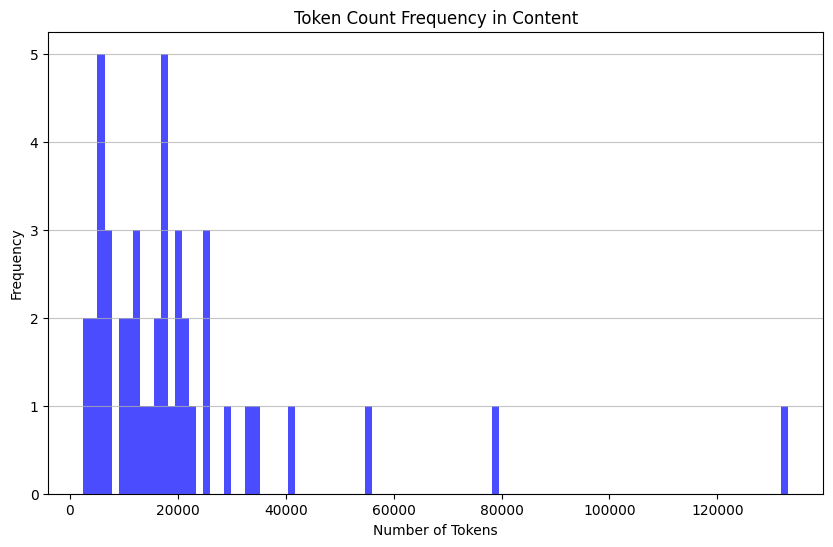

In [ ]:
import tiktoken
import matplotlib.pyplot as plt

def num_tokens_from_string(string:str, encoding_name:str) -> int:
  encoding = tiktoken.get_encoding(encoding_name)
  num_tokens = len(encoding.encode(string))
  return num_tokens

metadata_final['Token Count'] = metadata_final['Content'].apply(lambda x: num_tokens_from_string(x if isinstance(x, str) else "", encoding_name="cl100k_base"))

# 토큰 개수 시각화
plt.figure(figsize=(10, 6))
plt.hist(metadata_final["Token Count"], bins=100, color="blue", alpha=0.7)
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.title("Token Count Frequency in Content")
plt.grid(axis='y', alpha=0.75)
plt.show()

- 대부분 0~20,000 토큰 범위에 몰려있음. 이 범위의 텍스트 가진 논문이 가장 많음.
- 일부 긴 텍스트나 상세한 논문

In [ ]:
#### RAG (Raptor RAG)

- indexing 방법은 여전히 고민중이긴 함..
  - Abstract
  - Keywords
  - Introduction
  -

### 디렉토리 생성해 데이터 추출

- 데이터 확보건

In [ ]:
#### 아직 미진행....
#### 여기서 텍스트, 이미지, figure 추출하고 저장
#### 아래는 프롬프트로 LLM 통해 텍스트화 (프롬프트 고도화도 포함)
#### 벡터 DB 저장
#### 벡터 DB 저장 내용 가져와 사용 방안
#### 각 유형 따라 결과 도출

- Test 위한 데이터 확보건

평가 (Regas, Langsmith, LLM as a judge)


In [ ]:
!pip install -q langchain==0.2.16
!pip install -q ragas==0.1.19

In [4]:
import langchain
import ragas

print(f"LangChain Version: {langchain.__version__}")
print(f"Ragas Version: {ragas.__version__}")

LangChain Version: 0.2.17
Ragas Version: 0.1.19


In [ ]:
# RAGAS로 질문과 답변 생성하기(Synthethic Dataset)
"""
사용자들이 잠정적으로 만들어낼 수 있는 질문과 답변 생성
Seed Question > Evolver가 좋은지 안좋은지 평가 >
좋은 질문과 나쁜 질문을 구분하고 좋은 질문을 선별해 그것에 대한 답변 생성
Evolution은 Text를 정제하는 과정 > 실제로 질문 할 것 같은 질문으로 만들어줌
Evolution Process : reasoning, conditioning, multi-context ...
QA Validator가 Validation 진행 (Hallucination 안나오게)
"""

"filename이 있는지 확인함.(위에서 filename 변경)"

'filename이 있는지 확인함.(위에서 filename 변경)'

In [5]:
from ragas.testset.generator import TestsetGenerator
from ragas.testset.evolutions import simple, reasoning, multi_context, conditional
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas.testset.extractor import KeyphraseExtractor
from ragas.testset.docstore import InMemoryDocumentStore

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain.text_splitter import RecursiveCharacterTextSplitter

# 데이터셋 생성기
generator_llm = ChatOpenAI(model="gpt-4o-mini")
# 데이터셋 비평기
critic_llm = ChatOpenAI(model="gpt-4o-mini")
# 문서 임베딩
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

In [6]:
# docs 준비
import pandas as pd

df = pd.read_csv("/content/arxiv_article_data.csv")
df.head(3)

,Category,Query,Title,Summary,filename,Content,Token Count
0,cs,cat : cs.*,Brittle System Analysis,The goal of this paper is to define and anal...,http://arxiv.org/pdf/cs/9904016v1,"arXiv:cs/9904016v1 [cs.NI] 22 Apr 1999BUSH, ...",6319
1,cs,cat : cs.*,The Unix KISS: A Case Study,In this paper we show that the initial philo...,http://arxiv.org/pdf/cs/0701021v2,Perbandingan Shell Unix Oleh : Spits Warnars...,5133
2,cs,cat : cs.*,ASC-Hook: fast and transparent system call hoo...,Intercepting system calls is crucial for too...,http://arxiv.org/pdf/2412.05784v3,ASC-Hook: fast and transparent system call hoo...,11392


In [7]:
df.Category.unique()

array([' cs', ' math', ' physics', ' eess', ' econ', ' q-bio', ' q-fin',
       ' stat', ' astro-ph'], dtype=object)

In [8]:
# 카테고리별 데이터 분류 진행
cs_df = df[df['Category'] == ' cs']
math_df = df[df['Category'] == ' math']
physics_df = df[df['Category'] == ' physics']
eess_df = df[df['Category'] == ' eess']
econ_df = df[df['Category'] == ' econ']
qbio_df = df[df['Category'] == ' q-bio']
qfin_df = df[df['Category'] == ' q-fin']
stat_df = df[df['Category'] == ' stat']
astro_df = df[df['Category'] == ' astro-ph']

In [9]:
dataframes = {
    "cs_df":cs_df,
    "math_df":math_df,
    "physics_df":physics_df,
    "eess_df":eess_df,
    "econ_df":econ_df,
    "qbio_df":qbio_df,
    "qfin_df":qfin_df,
    "stat_df":stat_df,
    "astro_df":astro_df
}

In [10]:
from langchain.schema import Document

# 데이터프레임의 Content 열을 Document 객체 리스트로 변환
docs = [
    Document(
        page_content=row['Content'],  # 문서 내용
        metadata={
            "title": row['Title'],        # 문서 제목
            "category": row['Category'],  # 카테고리
            "query": row['Query'],        # 쿼리
            "filename": row['filename']   # PDF 링크
        }
    )
    for _, row in df.iterrows()
]

# 각 데이터프레임 변환 후 저장
for name, dataframe in dataframes.items():
    docs = [
        Document(
            page_content=row["Content"],
            metadata={
                "title": row["Title"],       # 문서 제목
                "category": row["Category"], # 카테고리
                "query": row["Query"],       # 쿼리
                "filename": row["filename"], # PDF 링크
            },
        )
        for _, row in dataframe.iterrows()
    ]
    globals()[f"{name}_docs"] = docs  # 동적으로 변수명 설정

# 결과 확인
for name in dataframes.keys():
    variable_name = f"{name}_docs"
    print(f"{variable_name}: {len(globals()[variable_name])} documents")

cs_df_docs: 5 documents
math_df_docs: 5 documents
physics_df_docs: 5 documents
eess_df_docs: 5 documents
econ_df_docs: 5 documents
qbio_df_docs: 5 documents
qfin_df_docs: 5 documents
stat_df_docs: 5 documents
astro_df_docs: 5 documents


In [11]:
# 텍스트 분할기를 설정합니다.
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)

# LangChain의 ChatOpenAI 모델을 LangchainLLMWrapper로 감싸 Ragas와 호환되게 만듭니다.
langchain_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4o-mini"))

# 주요 구문 추출기를 초기화합니다. 위에서 정의한 LLM을 사용합니다.
keyphrase_extractor = KeyphraseExtractor(llm=langchain_llm)

# ragas_embeddings 생성
ragas_embeddings = LangchainEmbeddingsWrapper(embeddings)

# InMemoryDocumentStore를 초기화합니다.
# 이는 문서를 메모리에 저장하고 관리하는 저장소입니다.
docstore = InMemoryDocumentStore(
    splitter=splitter,
    embeddings=ragas_embeddings,
    extractor=keyphrase_extractor,
)

In [12]:
generator = TestsetGenerator.from_langchain(
    generator_llm,
    critic_llm,
    ragas_embeddings,
    docstore=docstore,
)

In [13]:
# 질문 유형별 분포 결정
# simple: 간단한 질문, reasoning: 추론이 필요한 질문, multi_context: 여러 맥락을 고려해야 하는 질문, conditional: 조건부 질문
distributions = {simple: 0.2, reasoning: 0.4, multi_context: 0.3, conditional: 0.1}

In [ ]:
# 테스트셋 생성
# docs: 문서 데이터, 10: 생성할 질문의 수, distributions: 질문 유형별 분포, with_debugging_logs: 디버깅 로그 출력 여부
"""
testset = generator.generate_with_langchain_docs(
    documents=docs,
    test_size=10,
    distributions=distributions,
    with_debugging_logs=True,
    raise_exceptions=False,
)
"""

'\ntestset = generator.generate_with_langchain_docs(\n    documents=docs,\n    test_size=10,\n    distributions=distributions,\n    with_debugging_logs=True,\n    raise_exceptions=False,\n)\n'

In [ ]:
# 문서를 기반으로 테스트셋 생성 및 동적 변수명 설정
"""
def generate_testset_with_global(generator, docs, test_size, distributions, variable_name):
    testset = generator.generate_with_langchain_docs(
        documents=docs,
        test_size=test_size,
        distributions=distributions,
        with_debugging_logs=True,
        raise_exceptions=False,
    )
    globals()[variable_name] = testset
    """

In [ ]:
cs_testset = generator.generate_with_langchain_docs(
    documents=cs_df_docs,
    test_size=10,
    distributions=distributions,
    with_debugging_logs=True,
    raise_exceptions=False,
)

In [ ]:
cs_test_df = cs_testset.to_pandas()
cs_test_df

,question,contexts,ground_truth,evolution_type,metadata,episode_done
0,What is the purpose of the multi-level trampol...,[is roughly the same because they use similar ...,The purpose of the multi-level trampoline desi...,simple,[{'title': 'ASC-Hook: fast and transparent sys...,True
1,What are the performance and compatibility lim...,"[segment called __PAGEZERO, preventing the app...",ASC-Hook does not support hooking vDSO-based s...,simple,[{'title': 'ASC-Hook: fast and transparent sys...,True
2,How does the BIO structure manage IO requests ...,[OS opti- mization layer before dispatching IO...,The BIO structure manages IO requests pre-stor...,reasoning,[{'title': 'Learnings from an Under the Hood A...,True
3,What makes UNIX stable and adaptable on variou...,[Perbandingan Shell Unix Oleh : Spits Warnar...,The UNIX system is considered stable and adapt...,reasoning,"[{'title': 'The Unix KISS: A Case Study', 'cat...",True
4,What connects ext4's data mgmt and write-ahead...,[ext4 and xfs file-systems which a re most wi...,The answer to given question is not present in...,reasoning,[{'title': 'Learnings from an Under the Hood A...,True
5,What affects Block IO on OSD workloads?,[for Object -Drive based object -stores. ...,The context does not provide specific informat...,reasoning,[{'title': 'Learnings from an Under the Hood A...,True
6,How does the block IO scheduler manage IO requ...,[OS opti- mization layer before dispatching IO...,The block IO scheduler manages IO request band...,multi_context,[{'title': 'Learnings from an Under the Hood A...,True
7,What are the benefits of host data mgmt in obj...,[hefty and redundant host ( OS + applica- tio...,The benefits of host data management in object...,multi_context,[{'title': 'Learnings from an Under the Hood A...,True
8,How does the trampoline help with SVC instruct...,[contain fewer SVC instructions compared to ot...,The trampoline helps with SVC instructions by ...,multi_context,[{'title': 'ASC-Hook: fast and transparent sys...,True
9,How do IO requests affect OS optimization with...,[OS opti- mization layer before dispatching IO...,The context discusses how the OS optimization ...,conditional,[{'title': 'Learnings from an Under the Hood A...,True


In [ ]:
cs_test_df.to_csv('cs_arxiv_testset.csv', index=False)

In [ ]:
math_testset = generator.generate_with_langchain_docs(
    documents=math_df_docs,
    test_size=10,
    distributions=distributions,
    with_debugging_logs=True,
    raise_exceptions=False,
)

In [15]:
math_test_df = math_testset.to_pandas()
math_test_df

,question,contexts,ground_truth,evolution_type,metadata,episode_done
0,What condition on a locale or a topological sp...,[such that U|=ϕ. Hint.Consider the join of all...,A condition on a locale or a topological space...,simple,[{'title': 'Generalized spaces for constructiv...,True
1,What is the role of the multiplicative submono...,[to a prime ideal Q≥P. The complement of Qis a...,"The role of the multiplicative submonoid, whic...",simple,"[{'title': 'Quantalic spectra of semirings', '...",True
2,How are \\( \\iota \\)-open/closed classes def...,[is a straight- forward generalization of mate...,"In \( \iota \)-metric spaces, an \( \iota \)-c...",reasoning,"[{'title': 'Analysis in J_2', 'category': ' ma...",True
3,How are projective modules linked to torsion-f...,[it seems unlikely that considerations of pure...,The context mentions that most of the non-triv...,reasoning,"[{'title': 'Constructing projective modules', ...",True
4,What's the role of a dual basis in universal o...,[the open prime monoidanti-ideals of a commuta...,The role of a dual basis in universal open pri...,reasoning,"[{'title': 'Quantalic spectra of semirings', '...",True
5,"What degree did Arthur Mattuck get in '54, and...",[Cheval- ley’s Fundamental concepts of algebra...,Arthur Mattuck received his Ph.D. in 1954 unde...,reasoning,"[{'title': 'Constructing projective modules', ...",True
6,How does overtness affect existential quantifi...,[of the quantic spectrum. Remark 3.2.3. This d...,The concept of overtness allows for the existe...,multi_context,"[{'title': 'Quantalic spectra of semirings', '...",True
7,What role do continuous real-valued functions ...,[such that U|=ϕ. Hint.Consider the join of all...,The answer to given question is not present in...,multi_context,[{'title': 'Generalized spaces for constructiv...,True
8,What key Eilenberg-Mac Lane interactions shape...,"[is recou nted in other sources, with varying ...",The context discusses the interactions between...,multi_context,"[{'title': 'Constructing projective modules', ...",True
9,What are the effects of non-preserving propert...,[that 0+≤aanda+a≤a. It is easy to these elemen...,The effects of non-preserving properties on di...,conditional,"[{'title': 'Quantalic spectra of semirings', '...",True


In [16]:
math_test_df.to_csv('math_arxiv_testset.csv', index=False)

In [ ]:
physics_testset = generator.generate_with_langchain_docs(
    documents=physics_df_docs,
    test_size=10,
    distributions=distributions,
    with_debugging_logs=True,
    raise_exceptions=False,
)

physics_test_df = physics_testset.to_pandas()
physics_test_df

In [18]:
physics_test_df

,question,contexts,ground_truth,evolution_type,metadata,episode_done
0,What is the significance of the Méthode Alexan...,"[l donne imm´ ediatement, de la mani` ere la p...",The significance of the Méthode Alexander–Lera...,simple,"[{'title': 'Constructing projective modules', ...",True
1,What role does first-order predicate logic pla...,[Lemma 8.3. Both subdirect products (8.1)and(8...,The answer to given question is not present in...,simple,[{'title': 'Von Neumann coordinatization is no...,True
2,Which films show sci-fi flaws in physics?,[arXiv:0707.1167v1 [physics.soc-ph] 9 Jul 20...,The answer to given question is not present in...,reasoning,[{'title': 'Hollywood Blockbusters: Unlimited ...,True
3,What's the link between algebraic vector bundl...,[have been identiﬁed as algebro-geometr ic ana...,The context discusses the identification of al...,reasoning,"[{'title': 'Constructing projective modules', ...",True
4,What are the implications of extending sheaf s...,[to assume that Aitself is nontrivial. Give a ...,The implications of extending sheaf semantics ...,reasoning,[{'title': 'Generalized spaces for constructiv...,True
5,What defines a \ud835\udc56-class function reg...,[them). Deﬁnition 2.4. Anι-relation on anι-cla...,The context does not provide a specific defini...,reasoning,"[{'title': 'Analysis in J_2', 'category': ' ma...",True
6,What's the role of the neutral ideal In = π⁻¹{...,"[cpis a central idempotent of R, for each prim...",The context does not provide specific informat...,multi_context,[{'title': 'Von Neumann coordinatization is no...,True
7,What are the implications of extending sheaf s...,"[ideal, and such that it is not the case that,...",The implications of extending sheaf semantics ...,multi_context,[{'title': 'Generalized spaces for constructiv...,True
8,What are the implications of a global section ...,[sensible answer is “except f or the empty ope...,The implications of a global section in sheaf ...,multi_context,[{'title': 'Generalized spaces for constructiv...,True
9,What role do multi-variable analytic functions...,[enterprise in Fra nce was considerably dimin-...,The answer to given question is not present in...,conditional,"[{'title': 'Constructing projective modules', ...",True


In [19]:
physics_test_df.to_csv('physics_arxiv_testset.csv', index=False)

In [ ]:
eess_testset = generator.generate_with_langchain_docs(
    documents=eess_df_docs,
    test_size=10,
    distributions=distributions,
    with_debugging_logs=True,
    raise_exceptions=False,
)

eess_test_df = eess_testset.to_pandas()

In [21]:
eess_test_df

,question,contexts,ground_truth,evolution_type,metadata,episode_done
0,What demographic information was collected abo...,[of Southern California (USC). The data were c...,The demographic information collected about th...,simple,[{'title': 'A multispeaker dataset of raw and ...,True
1,What is the significance of geometric logic in...,"[Math. Structures Comp. Sci. 15 (6), 1089–1149...",The answer to given question is not present in...,simple,[{'title': 'Generalized spaces for constructiv...,True
2,How do finitely generated ideals affect quanta...,[(though a constructive ring-theoretic proof o...,The answer to given question is not present in...,reasoning,"[{'title': 'Quantalic spectra of semirings', '...",True
3,"What links localic semirings, commutative mono...",[Consider the following conditions: i)MMis a f...,The context discusses that a regular commutati...,reasoning,"[{'title': 'Quantalic spectra of semirings', '...",True
4,How do 'i-sets' relate to 'i-classes' in terms...,[is some sense in which the universe of sets c...,The answer to given question is not present in...,reasoning,"[{'title': 'Analysis in J_2', 'category': ' ma...",True
5,What must x and b meet to be a modular pair in...,[use for some more ﬁne-grained notions of modu...,"In a lattice, a pair of elements (x, b) is sai...",reasoning,"[{'title': 'Quantalic spectra of semirings', '...",True
6,What's the role of the ClopU to ClopV embeddin...,"[. Of course, both KandLare 2-distributive com...",The role of the ClopU to ClopV embedding in 2-...,multi_context,[{'title': 'Von Neumann coordinatization is no...,True
7,What social and political factors shaped proje...,[and sheaves as way-station in formulating “gl...,The social and political factors that shaped p...,multi_context,"[{'title': 'Constructing projective modules', ...",True
8,What aspects of group constructions and homomo...,[essentially the study of those constructions ...,A vague idea of covariance and contravariance ...,multi_context,"[{'title': 'Constructing projective modules', ...",True
9,What does category theory imply for math struc...,"[Math. Structures Comp. Sci. 15 (6), 1089–1149...",The answer to given question is not present in...,conditional,[{'title': 'Generalized spaces for constructiv...,True


In [22]:
eess_test_df.to_csv('eess_arxiv_testset.csv', index=False)

In [ ]:
econ_testset = generator.generate_with_langchain_docs(
    documents=econ_df_docs,
    test_size=10,
    distributions=distributions,
    with_debugging_logs=True,
    raise_exceptions=False,
)

econ_test_df = econ_testset.to_pandas()

In [24]:
econ_test_df

,question,contexts,ground_truth,evolution_type,metadata,episode_done
0,What are mathematical frames and how are they ...,[Assume pholds. Then/logicalortext{1|q}is a co...,Mathematical frames are best viewed as algebra...,simple,"[{'title': 'Quantalic spectra of semirings', '...",True
1,What were the economic effects of the trade co...,"[“fonte de atrito”, “ tensão social ”, “magne ...",The economic effects of the trade collapse on ...,simple,[{'title': 'Scientific Metaphors in the journa...,True
2,How does structure fit into Bourbaki's math?,"[i n a systematic and uni- ﬁed fashion, within...",The answer to given question is not present in...,reasoning,"[{'title': 'Constructing projective modules', ...",True
3,What challenges does RT-MRI face with quick vo...,"[a recognized impact in, for example, the doma...",RT-MRI faces several challenges with quick voc...,reasoning,[{'title': 'A multispeaker dataset of raw and ...,True
4,"What links semirings, quantales, and ideals?","[of quantales, where the counit is given by th...",The answer to given question is not present in...,reasoning,"[{'title': 'Quantalic spectra of semirings', '...",True
5,How do parallel filter banks boost signal proc...,[The ﬁlter coefﬁcients are grouped in a two st...,Parallel filter banks boost signal processing ...,reasoning,[{'title': 'Optimized Sharing of Coefficients ...,True
6,What links the quantale framework of monoid id...,"[monoid (M,µ×,ε1)deﬂationary if µ×≤ι1. Proposi...",The quantale framework of monoid ideals is lin...,multi_context,"[{'title': 'Quantalic spectra of semirings', '...",True
7,What role do classical physics metaphors like ...,"[“amigo chegado ”, “manter a distância patrão ...","Classical physics metaphors, such as 'social t...",multi_context,[{'title': 'Scientific Metaphors in the journa...,True
8,How do muscle flexion and friction help Aeon b...,[feet. In an eﬀort to exaggerate the abilities...,Muscle flexion helps Aeon maintain her balance...,multi_context,[{'title': 'Hollywood Blockbusters: Unlimited ...,True
9,What benefits do parallel filter banks provide...,[The ﬁlter coefﬁcients are grouped in a two st...,Parallel filter banks provide benefits for rad...,conditional,[{'title': 'Optimized Sharing of Coefficients ...,True


In [25]:
econ_test_df.to_csv('econ_arxiv_testset.csv', index=False)

In [ ]:
qbio_testset = generator.generate_with_langchain_docs(
    documents=qbio_df_docs,
    test_size=10,
    distributions=distributions,
    with_debugging_logs=True,
    raise_exceptions=False,
)

qbio_test_df = qbio_testset.to_pandas()

In [27]:
qbio_test_df

,question,contexts,ground_truth,evolution_type,metadata,episode_done
0,What is the significance of public belief conv...,"[the occurrence of cascades (see [13]), assumi...",The significance of public belief convergence ...,simple,[{'title': 'A Practical Approach to Social Lea...,True
1,What does the concept of 'not equal' imply in ...,[not notequal does not imply that they are act...,The concept of 'not equal' in the context of s...,simple,[{'title': 'Generalized spaces for constructiv...,True
2,What map comes from the initial homomorphism i...,[to algebraic geometry. Deﬁnition 1.8.1. LetRb...,The answer to given question is not present in...,reasoning,"[{'title': 'Quantalic spectra of semirings', '...",True
3,What role do normal epimorphisms play in subob...,[the autoduality Sup∼=Supop. This exchanges 0w...,The context does not provide specific informat...,reasoning,"[{'title': 'Quantalic spectra of semirings', '...",True
4,How do consumer prefs link to WTP for quality?,[of consumers to pay for the attributes of the...,The answer to given question is not present in...,reasoning,[{'title': 'Identification of hedonic equilibr...,True
5,What applies to Jacobi representations in impr...,"[oflemma 2.2 . Thus, 1´λty,zuis nonzero and we...",The answer to given question is not present in...,reasoning,[{'title': 'Second-order Inductive Inference: ...,True
6,What are the implications of a global section ...,[sensible answer is “except f or the empty ope...,The implications of a global section in sheaf ...,multi_context,[{'title': 'Generalized spaces for constructiv...,True
7,What's the role of functor OPAIR in localic se...,[The resulting equaliser can be explicitly des...,The functor OPAIR plays a role in describing t...,multi_context,"[{'title': 'Quantalic spectra of semirings', '...",True
8,What multivariate quantile concept relates to ...,[Henry (2012) proposea notion o f multivariate...,The multivariate quantile concept that relates...,multi_context,[{'title': 'Identification of hedonic equilibr...,True
9,What role does marginal distribution play in h...,[the limit ¯P. By the stability of optimal tra...,The answer to given question is not present in...,conditional,[{'title': 'Identification of hedonic equilibr...,True


In [28]:
qbio_test_df.to_csv('qbio_arxiv_testset.csv', index=False)

In [ ]:
qfin_testset = generator.generate_with_langchain_docs(
    documents=qfin_df_docs,
    test_size=10,
    distributions=distributions,
    with_debugging_logs=True,
    raise_exceptions=False,
)

qfin_test_df = qfin_testset.to_pandas()

In [30]:
qfin_test_df

,question,contexts,ground_truth,evolution_type,metadata,episode_done
0,What condition must a ring satisfy to be class...,[regardedasapproximationsto the hypotheticaltr...,The answer to given question is not present in...,simple,[{'title': 'Generalized spaces for constructiv...,True
1,What role did projective modules play in the d...,[inﬂuence of category-theoretic ideas in topol...,Projective modules initially were isolated as ...,simple,"[{'title': 'Constructing projective modules', ...",True
2,What made projective modules go from handy to ...,[inﬂuence of category-theoretic ideas in topol...,Projective modules transitioned from being obj...,reasoning,"[{'title': 'Constructing projective modules', ...",True
3,"What links local systems, cohomology, and Lera...","[cohomology [Sem55a, Expose 6]. In the expos ´...","The context discusses local systems of groups,...",reasoning,"[{'title': 'Constructing projective modules', ...",True
4,What metabolic changes happen for low vs. high...,[weight of these 𝑛compounds of interest is giv...,"In centrabolic samples, for low molecular weig...",reasoning,[{'title': 'Infer metabolic velocities from mo...,True
5,How do CVA differences for a 6-month single pa...,[true (or risky or defaultable) portfolio val...,The results demonstrate that the CVAs under bo...,reasoning,[{'title': 'Pricing Financial Derivatives Subj...,True
6,How do maximal ideals in Gelfand's spectrum di...,"[thereafter, Gelfand developed a spectrum for ...",Maximal ideals in Gelfand's spectrum differ fr...,multi_context,"[{'title': 'Quantalic spectra of semirings', '...",True
7,What challenges do researchers face in experim...,"[information revealed by this action history, ...",The main challenge facing researchers in exper...,multi_context,[{'title': 'A Practical Approach to Social Lea...,True
8,"What does Bourbaki represent for math unity, a...",[[Bou50] . The Bourbaki ideology included vari...,Bourbaki represents a quest for unification an...,multi_context,"[{'title': 'Constructing projective modules', ...",True
9,How do cellular processes affect tissue shapes...,[which play a key role in determining cellu...,The answer to given question is not present in...,conditional,[{'title': 'Acto-myosin clusters as active uni...,True


In [31]:
qfin_test_df.to_csv('qfin_arxiv_testset.csv', index=False)

In [ ]:
stat_testset = generator.generate_with_langchain_docs(
    documents=stat_df_docs,
    test_size=10,
    distributions=distributions,
    with_debugging_logs=True,
    raise_exceptions=False,
)

stat_test_df = stat_testset.to_pandas()

In [33]:
stat_test_df

,question,contexts,ground_truth,evolution_type,metadata,episode_done
0,What role does self-organisation play in the f...,[including the order in which the various ...,Self-organisation plays a crucial role in the ...,simple,[{'title': 'Acto-myosin clusters as active uni...,True
1,What role does the localisation process play i...,"[=/angbracketleftx0,x1|x0≤x1/angbracketright. ...",The answer to given question is not present in...,simple,"[{'title': 'Quantalic spectra of semirings', '...",True
2,"What are the implications of sublocales, their...",[the theory of ‘places at which elements of Rc...,The implications of sublocales in frame theory...,reasoning,"[{'title': 'Quantalic spectra of semirings', '...",True
3,What makes those focused on now put off boring...,[and encouraging comments. Part of the work on...,Individuals who are present-focused tend to pr...,reasoning,[{'title': 'Identifying Present-Bias from the ...,True
4,What causes acto-myosin gels to cluster on the...,[including the order in which the various ...,Acto-myosin gels can cluster on their own due ...,reasoning,[{'title': 'Acto-myosin clusters as active uni...,True
5,What impact did Artin have on Lang and others ...,"[is a parallel development, not overlapping wi...",The answer to given question is not present in...,reasoning,"[{'title': 'Constructing projective modules', ...",True
6,What are the implications of the Yoneda lemma ...,[By the Prime Ideal Theorem for rings there is...,The Yoneda lemma implies that any natural tran...,multi_context,"[{'title': 'Quantalic spectra of semirings', '...",True
7,What sets apart consumption for capital format...,[so that he/she can perform his/her job in th...,"Consumption for capital formation, referred to...",multi_context,[{'title': 'Sectorial Exclusion Criteria in th...,True
8,What limitation in bio circuitry comes from as...,"[own, mathematical modelling is playing an inc...",The limitation in bio circuitry that comes fro...,multi_context,[{'title': 'Prediction of cellular burden with...,True
9,Which factors help spot invisible metaphors in...,[ou de dicionários/enciclopédias científicas ...,The answer to given question is not present in...,conditional,[{'title': 'Scientific Metaphors in the journa...,True


In [34]:
stat_test_df.to_csv('stat_arxiv_testset.csv', index=False)

In [ ]:
astro_testset = generator.generate_with_langchain_docs(
    documents=astro_df_docs,
    test_size=10,
    distributions=distributions,
    with_debugging_logs=True,
    raise_exceptions=False,
)

astro_test_df = astro_testset.to_pandas()

In [36]:
astro_test_df

,question,contexts,ground_truth,evolution_type,metadata,episode_done
0,What is the purpose of the quickselect algorit...,[Select element akas pivot at k; Build the set...,"The purpose of the quickselect algorithm, as d...",simple,[{'title': 'A practically efficient fixed-pivo...,True
1,What are the possible sources of detectable br...,[linear size Llocated at a dis-Fig. 7.— Bright...,Possible sources of detectable brightness temp...,simple,[{'title': 'Surveying the Dynamic Radio Sky wi...,True
2,What algebraic topology ideas came from Poicna...,[P. Alexandroff and A. Urysohn who wer e inter...,The answer to given question is not present in...,reasoning,"[{'title': 'Constructing projective modules', ...",True
3,What losses do liquidity providers face in cry...,[thought of as bucketed and are represented by...,"Liquidity providers face impermanent loss, whi...",reasoning,[{'title': 'UNISWAP: Impermanent Loss and Risk...,True
4,How does the ε-function relate to total bounde...,[somen≤m. If such an mexists for eachkthen we ...,The answer to given question is not present in...,reasoning,"[{'title': 'Analysis in J_2', 'category': ' ma...",True
5,What two service aspects should Marxist analys...,[support from their husbands)? And what about ...,Marxist analysis of services should address th...,reasoning,[{'title': 'Sectorial Exclusion Criteria in th...,True
6,What allows transient acto-myosin clusters to ...,[Fig. 8B. Descriptions that include filament...,Transient acto-myosin clusters are proposed to...,multi_context,[{'title': 'Acto-myosin clusters as active uni...,True
7,What funding strategies support lab astrophysi...,[NSF Division of Astronom ical Sciences Advan...,The context does not provide specific funding ...,multi_context,[{'title': 'Laboratory Astrophysics and the St...,True
8,How does the affine short-rate process help ke...,"[by: P(t, T;ϑ) =Z [a,b]P(t, T;θ)dFϑ(θ) =Z [a,b...",The affine short-rate process helps keep rando...,multi_context,[{'title': 'Randomization of Short-Rate Models...,True
9,What roles do acto-myosin clusters play in fas...,[Fig. 8B. Descriptions that include filament...,Acto-myosin clusters are proposed to play a ro...,conditional,[{'title': 'Acto-myosin clusters as active uni...,True


In [37]:
astro_test_df.to_csv('astro_arxiv_testset.csv', index=False)

In [ ]:
#### 위 df 확보시 Q&A, GT 생성
#### Test (RAGAS / LLM as a Judge / langchain evaluate)

- 추가 실험 건

In [ ]:
#### LLM >>> sLM
#### 오픈소스, 비용 낮춰도 가능하게
#### 프롬프틑 고도화

### Test 전 Demo

**기존 쿼리 기반 추출 코드(Basic) - Metadata**

In [ ]:
"""
import os
import pandas as pd
from langchain.document_loaders import ArxivLoader
from pdf2image import convert_from_path
from huggingface_hub import hf_hub_download
import cv2
from doclayout_yolo import YOLOv10
from PIL import Image

# ArxivLoader를 활용해 논문을 가져옵니다
loader = ArxivLoader(
    query="Agent",
    load_max_docs=20,              # 최대 문서 수
    load_all_available_meta=True   # 메타데이터 전체 로드 여부
)
docs = loader.load()

# 메타데이터 정보를 데이터프레임으로 저장
metadata_list = []
for doc in docs:
    metadata = doc.metadata
    metadata_list.append({
        'Title': metadata.get('Title', ''),
        'Summary': metadata.get('Summary', ''),
        'PDF Link': metadata.get('links', [])[-1] if metadata.get('links') else ''
    })

dataframe = pd.DataFrame(metadata_list)

# 데이터프레임 확인
print(dataframe)

# DocLayout-YOLO 및 필수 패키지 설치
os.system("pip install git+https://github.com/opendatalab/DocLayout-YOLO.git")
os.system("pip install pdf2image huggingface_hub")
os.system("sudo apt-get install poppler-utils")

# PDF 다운로드 함수
def download_pdf(pdf_url, filename):
    import requests
    response = requests.get(pdf_url)
    with open(filename, 'wb') as f:
        f.write(response.content)
    print(f"Downloaded: {filename}")

# PDF를 이미지로 변환
def convert_pdf_to_images(pdf_path, output_dir):
    try:
        os.makedirs(output_dir, exist_ok=True)
        images = convert_from_path(pdf_path)
        image_paths = []
        for i, image in enumerate(images):
            image_path = os.path.join(output_dir, f"page_{i+1}.jpg")
            image.save(image_path, "JPEG")
            image_paths.append(image_path)
        print(f"Converted {pdf_path} to images in {output_dir}")
        return image_paths
    except Exception as e:
        print(f"Error converting {pdf_path} to images: {e}")
        return []

# DocLayout-YOLO를 활용한 디텍션 및 저장

def extract_content_with_doclayout_yolo(image_paths, output_dir, pdf_index):
    os.makedirs(output_dir, exist_ok=True)

    # Pre-trained 모델 다운로드 및 로드
    model_path = hf_hub_download(repo_id="juliozhao/DocLayout-YOLO-DocStructBench", filename="doclayout_yolo_docstructbench_imgsz1024.pt")
    model = YOLOv10(model_path)

    metadata = []

    for page_number, image_path in enumerate(image_paths, start=1):
        # 모델 예측
        det_res = model.predict(
            source=image_path,   # 이미지 경로
            imgsz=1024,          # 예측 이미지 크기
            conf=0.2,            # 신뢰도 임계값
            device="cpu"         # CPU에서 실행
        )

        # 결과 필터링 및 저장
        for det in det_res[0].boxes:
            bbox = det.xyxy.numpy().flatten()  # 바운딩 박스 좌표 추출
            cls = int(det.cls.cpu().numpy())  # 클래스 인덱스 추출
            label = model.names[cls]

            if label in ["table","table_caption","table_footnote", "figure", "figure_caption","isolate_formula","formula_caption"]:
                image = Image.open(image_path)
                cropped = image.crop((bbox[0], bbox[1], bbox[2], bbox[3]))

                output_label_dir = os.path.join(output_dir, label + "s")
                os.makedirs(output_label_dir, exist_ok=True)
                output_image_path = os.path.join(output_label_dir, os.path.basename(image_path).replace(".jpg", f"_{label}.jpg"))
                cropped.save(output_image_path)
                print(f"Saved {label} to {output_image_path}")

                metadata.append({
                    "pdf_index": pdf_index,
                    "page_number": page_number,
                    "label": label,
                    "bbox": bbox.tolist(),
                    "output_path": output_image_path
                })

    return metadata

# PDF 다운로드 및 콘텐츠 추출 함수
def save_pdfs_and_extract_content(dataframe):
    extracted_data_dir = "extracted_data"
    os.makedirs(extracted_data_dir, exist_ok=True)

    all_metadata = []

    for index, row in dataframe.iterrows():
        pdf_link = row['PDF Link']
        title = row['Title']
        if pdf_link:
            pdf_filename = os.path.join(extracted_data_dir, f"paper_{index+1}.pdf")
            download_pdf(pdf_link, pdf_filename)

            # PDF를 이미지로 변환
            image_output_dir = os.path.join(extracted_data_dir, f"paper_{index+1}_images")
            image_paths = convert_pdf_to_images(pdf_filename, image_output_dir)

            if image_paths:
                # DocLayout-YOLO 디텍션 및 결과 저장
                content_output_dir = os.path.join(extracted_data_dir, f"paper_{index+1}_content")
                metadata = extract_content_with_doclayout_yolo(image_paths, content_output_dir, pdf_index=index+1)
                all_metadata.extend(metadata)
                print(f"Extracted content from {pdf_filename} saved to {content_output_dir}")

    # 메타데이터를 CSV로 저장
    metadata_df = pd.DataFrame(all_metadata)
    metadata_df.to_csv(os.path.join(extracted_data_dir, "detection_metadata.csv"), index=False)
    print(f"Detection metadata saved to {os.path.join(extracted_data_dir, 'detection_metadata.csv')}.")

# 함수 실행
save_pdfs_and_extract_content(dataframe)
"""